In [1]:
import glob
import numpy as np
import uproot
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [2]:
parents = {
    111: (r"$\pi^0$", 0.1349768, 0.98823, 0, "pi0"),
    221: (r"$\eta$", 0.5478620, 0.39410, 0, "eta"),
    331: (r"$\eta'$", 0.9577800, 0.0220, 0, "etap"),
    113: (r"$\rho$", 0.7752600, 4.72e-5, 1, "rho0"),
    223: (r"$\omega$", 0.7826500, 7.36e-5, 1, "omega"),
    333: (r"$\phi$", 1.0194610, 2.973e-4, 1, "phi"),
    443: (r"$J/\psi$", 3.0969000, 5.971e-2, 1, "jpsi"),
}

SOURCE = "meson"                    # "meson" or "dy"
MASS = 0.02266106
mass_tag = f"{MASS:.6f}".replace(".", "p")
MESON_PDG = 111

In [3]:
if SOURCE == "meson":
    label, parent_mass, br_ref, kind, emitter = parents[MESON_PDG]

    files = glob.glob(
        f"/pscratch/sd/h/hogcai/mcp-meson-production-50pt/raw/"
        f"emitter_{emitter}/mass_{mass_tag}/*.root"
    )

    d = uproot.concatenate(
        [f"{p}:mcp_spectra" for p in files],
        ["mcp_pdg", "E_GeV", "theta_rad", "theta_x_rad", "theta_y_rad", "passed_geometry"],
        library="np",
    )

    keep = d["passed_geometry"] == 1

else:
    label = "DY"

    files = glob.glob(
        f"../2x2MCP-DY/outputs/production/"
        f"emitter_dy/mass_{mass_tag}/*.root"
    )

    d = uproot.concatenate(
        [f"{p}:mcp_spectra" for p in files],
        ["mcp_pdg", "E_GeV", "theta_rad", "theta_x_rad", "theta_y_rad", "accepted"],
        library="np",
    )

    keep = d["accepted"] == 1

In [4]:
energy = d["E_GeV"][keep]
theta = d["theta_rad"][keep] * 1e3
theta_x = d["theta_x_rad"][keep]
theta_y = d["theta_y_rad"][keep]
mcp_pdg = d["mcp_pdg"][keep]

In [5]:
print(f"{label}, mass={MASS:g} GeV")
print(f"files={len(files)}, accepted MCPs={len(energy)}")

$\pi^0$, mass=0.0226611 GeV
files=10, accepted MCPs=13574


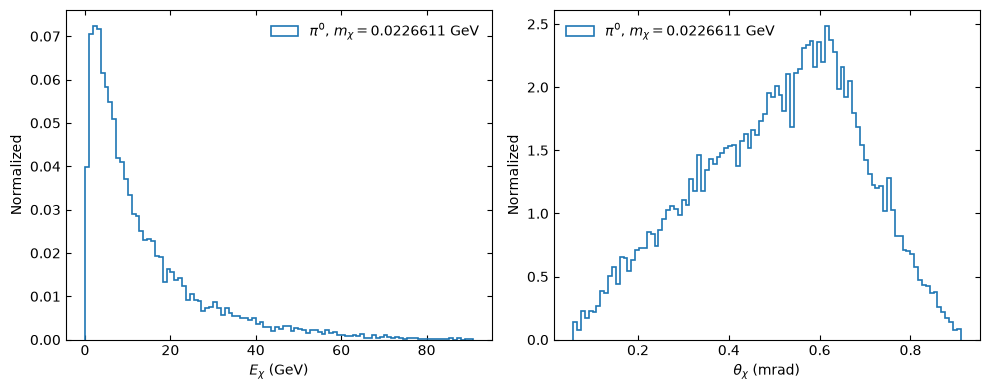

In [6]:
BINS = 100

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(
    energy,
    bins=BINS,
    density=True,
    histtype="step",
    linewidth=1.2,
    label=rf"{label}, $m_\chi={MASS:g}$ GeV",
)

ax[1].hist(
    theta,
    bins=BINS,
    density=True,
    histtype="step",
    linewidth=1.2,
    label=rf"{label}, $m_\chi={MASS:g}$ GeV",
)

ax[0].set(xlabel=r"$E_\chi$ (GeV)", ylabel="Normalized")
ax[1].set(xlabel=r"$\theta_\chi$ (mrad)", ylabel="Normalized")

for a in ax:
    a.tick_params(which="both", direction="in", top=True, right=True)
    a.legend(frameon=False)

plt.tight_layout()
plt.show()

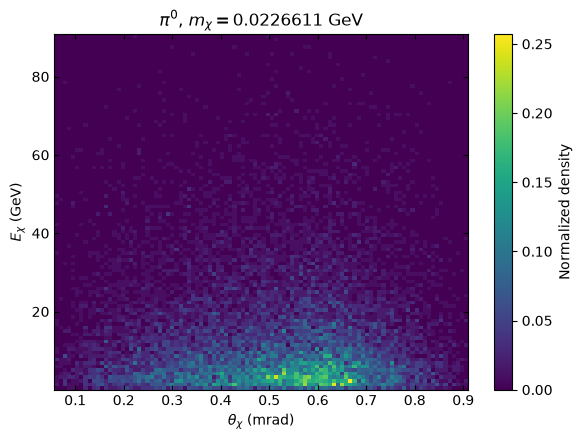

In [7]:
plt.figure(figsize=(6, 4.5))

h = plt.hist2d(
    theta,
    energy,
    bins=100,
    density=True,
    cmap="viridis",
)

plt.xlabel(r"$\theta_\chi$ (mrad)")
plt.ylabel(r"$E_\chi$ (GeV)")
plt.title(rf"{label}, $m_\chi={MASS:g}$ GeV")
plt.colorbar(h[3], label="Normalized density")
plt.tick_params(which="both", direction="in", top=True, right=True)
plt.tight_layout()
plt.show()

In [20]:
keep = (energy > MASS) & np.isfinite(theta_x) & np.isfinite(theta_y)
energy_original = energy[keep]
theta_x_original = theta_x[keep]
theta_y_original = theta_y[keep]
mcp_pdg_original = mcp_pdg[keep]

theta_original = np.arctan(np.hypot(theta_x_original, theta_y_original)) * 1e3
phi_original = np.arctan2(theta_y_original, theta_x_original)
u_original = np.log(energy_original - MASS)
v_original = np.log(theta_original)

BINS_SAMPLE = 50
u_edges = np.linspace(u_original.min(), u_original.max(), BINS_SAMPLE + 1)
v_edges = np.linspace(v_original.min(), v_original.max(), BINS_SAMPLE + 1)
phi_edges = np.linspace(-np.pi, np.pi, BINS_SAMPLE + 1)

H, _ = np.histogramdd(
    (u_original, v_original, phi_original),
    bins=(u_edges, v_edges, phi_edges),
)
probability = H.ravel() / H.sum()

N_SAMPLE = 10_000_000
rng = np.random.default_rng(12124)
parts = [[], [], [], []]
remaining = N_SAMPLE

while remaining:
    selected = rng.choice(H.size, remaining, p=probability)
    iu, iv, ip = np.unravel_index(selected, H.shape)

    e = MASS + np.exp(rng.uniform(u_edges[iu], u_edges[iu + 1]))
    theta = np.exp(rng.uniform(v_edges[iv], v_edges[iv + 1]))
    phi = rng.uniform(phi_edges[ip], phi_edges[ip + 1])

    slope = np.tan(theta * 1e-3)
    tx, ty = slope * np.cos(phi), slope * np.sin(phi)
    x, y = 1040.0 * tx, 1040.0 * ty

    accept = (
        (((x >= -0.65) & (x <= -0.05)) |
         ((x >= 0.05) & (x <= 0.65))) &
        (y >= -0.70) & (y <= 0.70)
    )

    for part, values in zip(parts, (e, tx, ty, theta)):
        part.append(values[accept])

    remaining -= accept.sum()
    del selected, iu, iv, ip, e, theta, phi, slope, tx, ty, x, y, accept

energy_sampled, theta_x_sampled, theta_y_sampled, theta_sampled = [
    np.concatenate(part) for part in parts
]
mcp_pdg_sampled = rng.choice(mcp_pdg_original, N_SAMPLE)

assert len(energy_sampled) == N_SAMPLE
del parts

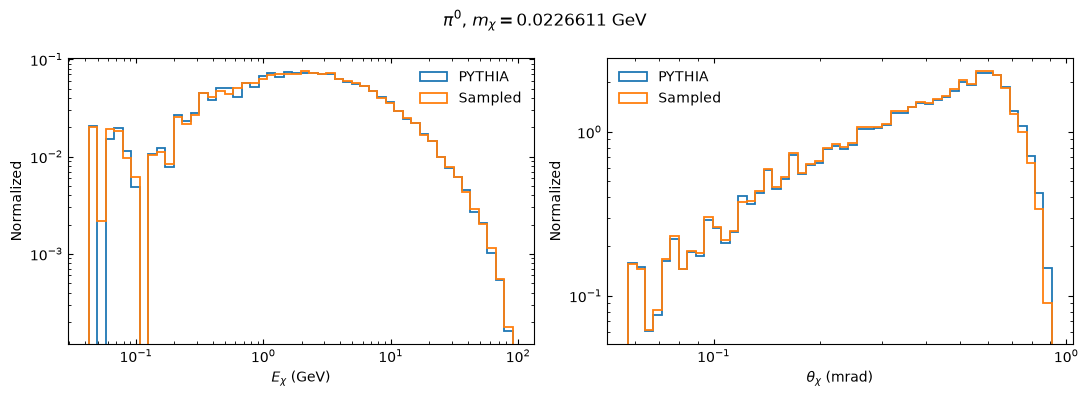

In [21]:
BINS = 50

energy_bins = np.geomspace(
    min(energy_original.min(), energy_sampled.min()),
    max(energy_original.max(), energy_sampled.max()),
    BINS + 1,
)
theta_bins = np.geomspace(
    min(theta_original.min(), theta_sampled.min()),
    max(theta_original.max(), theta_sampled.max()),
    BINS + 1,
)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].hist(energy_original, energy_bins, density=True,
           histtype="step", linewidth=1.3, label="PYTHIA")
ax[0].hist(energy_sampled, energy_bins, density=True,
           histtype="step", linewidth=1.3, label="Sampled")
ax[0].set(xscale="log", yscale="log",
          xlabel=r"$E_\chi$ (GeV)", ylabel="Normalized")
ax[0].legend(frameon=False)

ax[1].hist(theta_original, theta_bins, density=True,
           histtype="step", linewidth=1.3, label="PYTHIA")
ax[1].hist(theta_sampled, theta_bins, density=True,
           histtype="step", linewidth=1.3, label="Sampled")
ax[1].set(xscale="log", yscale="log",
          xlabel=r"$\theta_\chi$ (mrad)", ylabel="Normalized")
ax[1].legend(frameon=False)

for a in ax:
    a.tick_params(which="both", direction="in", top=True, right=True)

fig.suptitle(rf"{label}, $m_\chi={MASS:g}$ GeV")
plt.tight_layout()
plt.show()


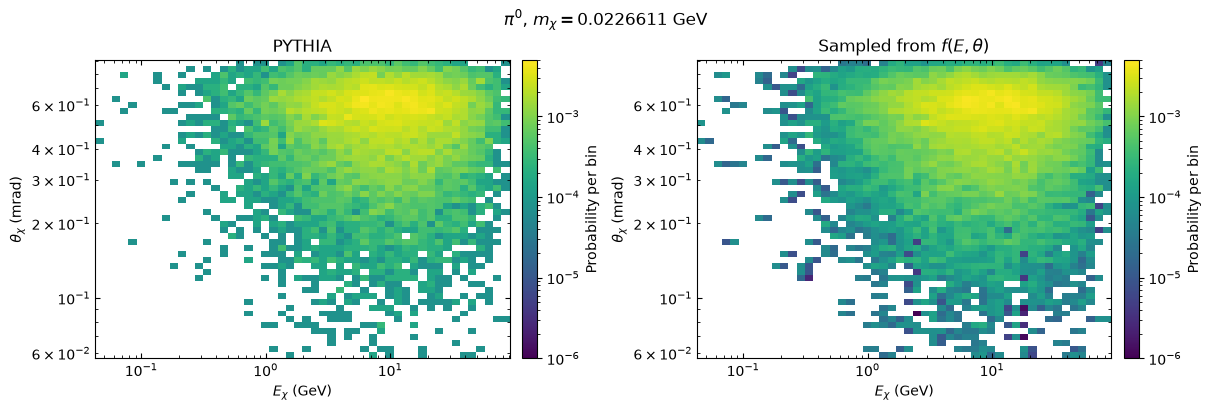

In [22]:
P0, _, _ = np.histogram2d(
    energy_original, theta_original,
    bins=[energy_bins, theta_bins]
)
P1, _, _ = np.histogram2d(
    energy_sampled, theta_sampled,
    bins=[energy_bins, theta_bins]
)

P0 /= P0.sum()
P1 /= P1.sum()

positive = np.r_[P0[P0 > 0], P1[P1 > 0]]
norm = LogNorm(vmin=positive.min(), vmax=positive.max())

fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

h0 = ax[0].pcolormesh(energy_bins, theta_bins, P0.T, norm=norm)
h1 = ax[1].pcolormesh(energy_bins, theta_bins, P1.T, norm=norm)

for a, title in zip(ax, ["PYTHIA", "Sampled from $f(E,\\theta)$"]):
    a.set(
        xscale="log", yscale="log",
        xlabel=r"$E_\chi$ (GeV)",
        ylabel=r"$\theta_\chi$ (mrad)",
        title=title
    )
    a.tick_params(which="both", direction="in", top=True, right=True)

fig.colorbar(h0, ax=ax[0], pad=0.03, label="Probability per bin")
fig.colorbar(h1, ax=ax[1], pad=0.03, label="Probability per bin")
fig.suptitle(rf"{label}, $m_\chi={MASS:g}$ GeV")
plt.show()

In [23]:
difference = P1 - P0
total_variation = 0.5 * np.abs(difference).sum()
max_bin_error = np.abs(difference).max()
rms_bin_error = np.sqrt(np.mean(difference**2))

print(f"Total variation error = {total_variation:.6f}")
print(f"Maximum bin error = {max_bin_error:.6e}")
print(f"RMS bin error = {rms_bin_error:.6e}")

Total variation error = 0.069191
Maximum bin error = 7.212778e-04
RMS bin error = 1.081469e-04


In [24]:
N_REAL = len(energy_original)
p = P0.ravel()

rng = np.random.default_rng(1234)
tv_stat = np.empty(1000)

for i in range(1000):
    q = rng.multinomial(N_REAL, p) / N_REAL
    tv_stat[i] = 0.5 * np.abs(q - p).sum()

print(f"Observed TV = {total_variation:.6f}")
print(f"Expected statistical TV = {np.median(tv_stat):.6f}")
print(f"68% interval = {np.percentile(tv_stat, 16):.6f} to {np.percentile(tv_stat, 84):.6f}")
print(f"95% upper limit = {np.percentile(tv_stat, 95):.6f}")

Observed TV = 0.069191
Expected statistical TV = 0.104317
68% interval = 0.101812 to 0.107117
95% upper limit = 0.108885


In [25]:
import pandas as pd

N = 10_000_000
E_GeV = energy_sampled[:N]
theta_x_rad = theta_x_sampled[:N]
theta_y_rad = theta_y_sampled[:N]
p_GeV = np.sqrt(E_GeV**2 - MASS**2)
direction_norm = np.sqrt(1.0 + theta_x_rad**2 + theta_y_rad**2)
L_DETECTOR_M = 1040.0
x_at_detector_m = L_DETECTOR_M * theta_x_rad
y_at_detector_m = L_DETECTOR_M * theta_y_rad
mcp_pdg_sampled = rng.choice(mcp_pdg_original, size=N)

passed_geometry = (
    (((x_at_detector_m >= -0.65) & (x_at_detector_m <= -0.05)) |
     ((x_at_detector_m >= 0.05) & (x_at_detector_m <= 0.65))) &
    (y_at_detector_m >= -0.70) & (y_at_detector_m <= 0.70)
)
assert passed_geometry.all()

pd.DataFrame({
    "event_index": np.arange(N),
    "mcp_pdg": mcp_pdg_sampled,
    "px_GeV": p_GeV * theta_x_rad / direction_norm,
    "py_GeV": p_GeV * theta_y_rad / direction_norm,
    "pz_GeV": p_GeV / direction_norm,
    "E_GeV": E_GeV,
    "x_at_detector_m": x_at_detector_m,
    "y_at_detector_m": y_at_detector_m,
}).to_csv("pi0_m0p0226611_10M.csv", index=False)